# Calculating Standardized Precipitation Index (SPI)

One of the key advantages of the [XEE](https://github.com/google/Xee) package is the ability to use Python packages to work with data from Google Earth Engine. This package allows you to easily extract data from the vast data catalog of GEE and use widely used implementations available as Python libraries.

## Overview of the Task

This notebook shows how to extract a precipitation time-series images from Earth Engine and then use the [Climate Indicies](https://climate-indices.readthedocs.io/en/latest/) Python package to calculate the Calculating Standardized Precipitation (SPI).


**Input Layers**:
* `ne_10m_admin_0_countries_ind.zip`: A shapefile of country boundaries


**Output Layers**:
*   `2024-01.tif`, `2024-02.tif` .... , `2024-12.tif` : GeoTIFF files of monthly SPI for the selected country.


**Data Credit**:
* Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.
* Muñoz Sabater, J., (2019): ERA5-Land monthly averaged data from 1981 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS). (2026-06-02), doi:10.24381/cds.68d2bb30



**Running the Notebook**:
The preferred way to run this notebook is on Google Colab.
<a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/xee_calculating_spi.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install climate-indices xee rioxarray dask['distributed']

In [2]:
import climate_indices
import datetime
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import rioxarray as rxr
import xarray as xr
from climate_indices import indices
from xee import helpers

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [ ]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

data_url = 'https://naciscdn.org/naturalearth/10m/cultural/'


shapefile = 'ne_10m_admin_0_countries_ind.zip'

download(data_url + shapefile)

## Initialize EE and Dask Cluster

Initialize EE with the [High-Volume EndPoint](https://developers.google.com/earth-engine/guides/processing_environments#high-volume_endpoint) which is recommended to be used with XEE for workflows that do not use a lot of server side processing and are primarily for extracting data from stored collections. Replace the value of the `cloud_project` variable with your own project id that is linked with GEE.


In [5]:
cloud_project = 'spatialthoughts' # replace with your project id

try:
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')
except:
    ee.Authenticate()
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')

Setup a local Dask cluster.

In [ ]:
from dask.distributed import Client

client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


Each of our Dask workers need Earth Engine authentication. Initialize Dask workers using `ee.Initialize()`.

In [ ]:
from dask.distributed import WorkerPlugin

class EEPlugin(WorkerPlugin):
    def __init__(self):
        pass
    def setup(self, worker):
        self.worker = worker
        try:
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')
        except:
            ee.Authenticate()
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')

ee_plugin = EEPlugin()
client.register_plugin(ee_plugin)


## Procedure

Load the Natural Earth Admin0 boundaries and extract the polygon for India.

In [9]:
shapefile_path = os.path.join(data_folder, shapefile)
gdf = gpd.read_file(shapefile_path, encoding='utf-8')
country = gdf[gdf['SOV_A3'] == 'IND']
geometry = country.geometry.union_all()

Now we have an ImageCollection that we want to get it as a XArray Dataset. We define the region of interest and extract the ImageCollection using the 'ee' engine.

In [10]:
era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
filtered = era5 \
  .filter(ee.Filter.date('1995-01-01', '2025-01-01')) \
  .select('total_precipitation_sum')

We now read the filtered collecting using XEE. XEE requires explicit grid parameters. We extract these using the helper function [`extract_grid_params`](hhttps://xee.readthedocs.io/en/latest/_autosummary/xee.extract_grid_params.html#xee.extract_grid_params).

In [11]:
grid_params = helpers.extract_grid_params(filtered)
grid_params

{'crs': 'EPSG:4326',
 'crs_transform': (0.1, 0, -180.05, 0, -0.1, 90.05),
 'shape_2d': (3601, 1801)}

In [12]:
ds = xr.open_dataset(
    filtered,
    engine='ee',
    **grid_params,
    chunks={}
)
ds

<xarray.Dataset> Size: 9GB
Dimensions:                  (time: 360, y: 1801, x: 3601)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 1995-01-01 ... 2024-12-01
  * y                        (y) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * x                        (x) float64 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    total_precipitation_sum  (time, y, x) float32 9GB dask.array<chunksize=(48, 256, 256), meta=np.ndarray>

Clip the pixels outside the geometry.

In [ ]:
clipped_ds = ds \
  .rio.clip(country.geometry.values)
clipped_ds

Check the size of the resulting dataset.

In [14]:
print(f'DataSet size: {clipped_ds.nbytes/1e6:.2f} MB.')

DataSet size: 126.99 MB.


Being small enough to fit into memory, we can speed up the downstream workflows by loading the results into memory using `.compute()`.

In [15]:
%%time
clipped_ds = clipped_ds.compute()

CPU times: user 1.61 s, sys: 464 ms, total: 2.08 s
Wall time: 28.2 s


Select the `total_precipitation_sum` variable. Many XArray functions require all the dimensions to be sorted in ascending order. Make sure `y` and `x` are sorted.

In [16]:
clipped_da = clipped_ds.total_precipitation_sum
clipped_da = clipped_da.sortby(['y', 'x'])

We now have a monthly precipitation time-series at each pixel. We can reformat the DataArray by grouping the time-series at each lat/lon.

In [32]:
da_precip_groupby = clipped_da.stack(pixel=('y', 'x')).groupby('pixel')

Configure the SPI calculation.

In [18]:
scale = 3
distribution = climate_indices.indices.Distribution.gamma
data_start_year = 1995
calibration_year_initial = 1995
calibration_year_final = 2024
periodicity = climate_indices.compute.Periodicity.monthly

def calculate_spi(group):
    spi_values = climate_indices.indices.spi(
        group.values,
        scale,
        distribution,
        data_start_year,
        calibration_year_initial,
        calibration_year_final,
        periodicity
    )
    return xr.DataArray(spi_values, coords={'time': group.time}, dims=['time'])

In [19]:
# supress info logging messages form climate_indices
import logging
logging.getLogger('climate_indices').setLevel(logging.WARNING)

In [ ]:
%%time
# apply SPI to each `pixel`

da_spi = da_precip_groupby.apply(calculate_spi)

Unstack the array back into original dimensions.

In [34]:
da_spi = da_spi.unstack('pixel')

## Visualize the Results

We use a faceted plot to visualize all months of a selected year.

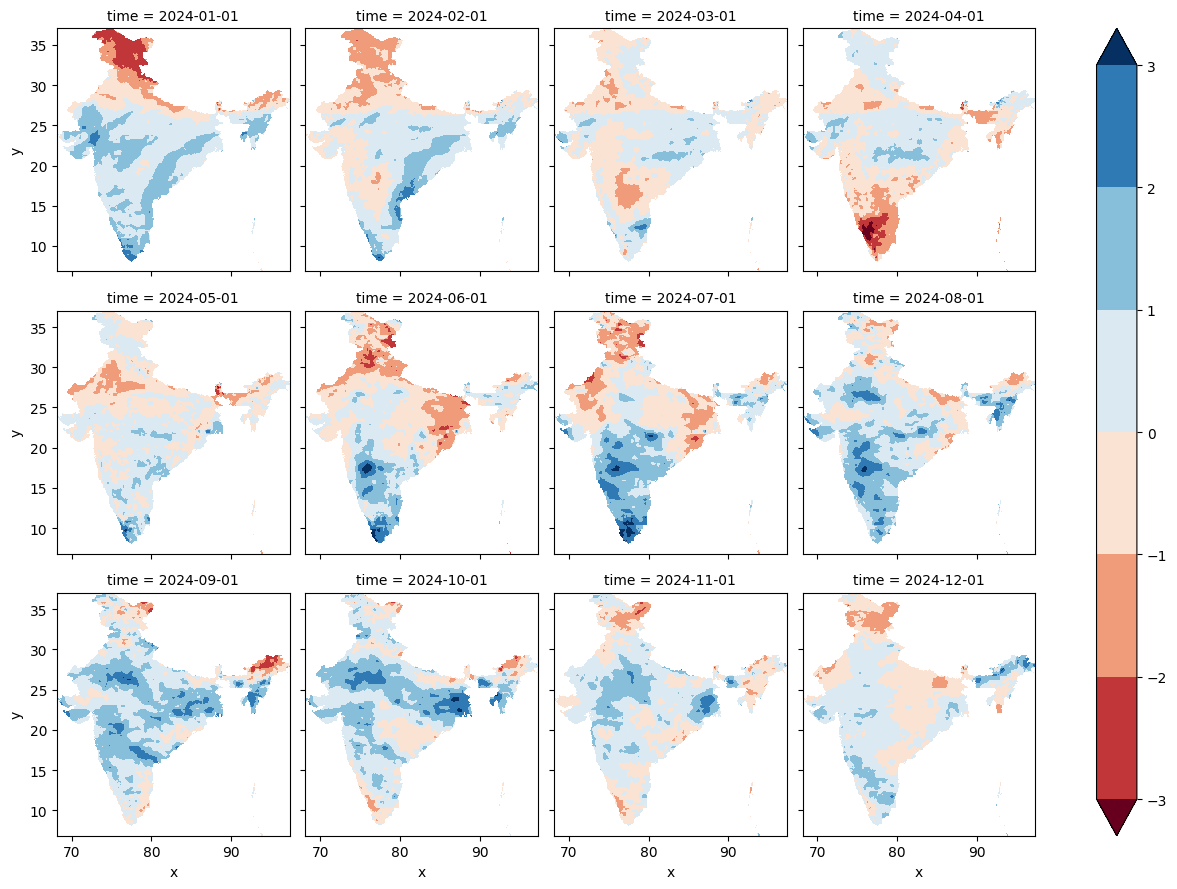

In [35]:
# select a year to visualize
selected = da_spi.sel(time='2024')

legend_levels = [-3,-2,-1,0,1,2,3]
selected.plot(cmap='RdBu', col='time', col_wrap=4, levels=legend_levels)
plt.show()

## Save Output as GeoTIFFs

We can use `rioxarray` to clip and save the resulting arrays as GeoTIFF files.

In [24]:
# select a year to save
selected = da_spi.sel(time='2024')

In [ ]:
for time in selected.time.values:
    date_string = np.datetime_as_string(time, unit='M')
    image = selected.sel(time=time) \
      .rio.write_crs('EPSG:4326') \
      .rio.clip(country.geometry.values)
    output_file = f'{date_string}.tif'
    output_path = os.path.join(output_folder, output_file)
    image.rio.to_raster(output_path, driver='COG')
    print(f'Saved {output_path}')

----

If you want to give feedback or share your experience with this tutorial, please comment below. (requires GitHub account)


<script src='https://utteranc.es/client.js'
    repo='spatialthoughts/geopython-tutorials'
    issue-term='pathname'
    theme='github-light'
    crossorigin='anonymous'
    async>
</script>